# [2] Download STAC Assets

> Download STAC Assets identified in the previous notebook.

---
__Last Update:__ June 19, 2026

### Imports + Config

In [0]:
import warnings
warnings.filterwarnings(
    "ignore",
    message=r".*make_tokens_by_line.*received a list of lines.*",
    category=UserWarning,
)

In [0]:
%run ./config_nb

__Libraries__

* GeoBrix assumed already installed on the cluster.
* Python bindings now are `databricks.labs.gbx.rasterx` (etc).
* Pandas now at 2.2.3 with DBR17.3
* Match GDAL to version installed with natives (3.11.4).

__Unity Catalog__

* Replace `catalog_name` and `schema_name` with your preferred locations.
* Volume 'data' must exist under `catalog_name`/`schema_name`.

Note: you may need to restart the kernel using %restart_python or dbutils.library.restartPython() to use updated packages.


... catalog: 'geospatial_docs' (USE)
... schema: 'eo_series' (CREATE / USE)


... ETL_DIR: '/Volumes/geospatial_docs/eo_series/data'
... EO_DIR: '/Volumes/geospatial_docs/eo_series/data/alaska' (MKDIRS)


# Shared Configuration Notebook

This notebook sets up the entire EO-Series pipeline. Every main notebook (`01.`, `02.`, `03.`, `04.`) runs `%run ./config_nb` to establish catalog / schema / Volume paths, install GeoBrix, instantiate the `StacClient`, and register shared helper functions.

...

... skipping spark.conf.set(spark.sql.adaptive.coalescePartitions.enabled) [Serverless?]: AnalysisException


True

... catalog: 'geospatial_docs' (USE)
... schema: 'eo_series' (CREATE / USE)


... ETL_DIR: '/Volumes/geospatial_docs/eo_series/data'
... EO_DIR: '/Volumes/geospatial_docs/eo_series/data/alaska' (MKDIRS)


## Helper Functions

`finalize_tiled_band_tbl` and `gen_tessellate_tiled_band` are shared pipeline utilities used by notebooks 03 and 04. They use `rst_srid` (extract CRS identifier), `rst_boundingbox` (spatial extent as WKB), `rst_initnodata` (mask nodata pixels), and `rst_memsize` (in-memory footprint) for ingestion, and invoke `gbx_rst_h3_tessellate` via a SQL LATERAL to assign each tile to its overlapping H3 cells. See [RasterX Functions](https://databrickslabs.github.io/geobrix/docs/api/raster-functions) and [H3 Raster Tessellation](https://databrickslabs.github.io/geobrix/docs/api/h3-raster-tessellation).

## Alaska STAC Asset Download

> We can easily extract the download links for items of interest. In this case, we will grab data within Alaska. Note: due to limitations in the [free tier for Planetary Computer](https://planetarycomputer.microsoft.com/docs/concepts/sas/), we will not attempt to get all available data within our time range. And to not make the example too large, we will just use a single county.

In [0]:
# FORCE_REBUILD=True # to rebuild all this

In [0]:
CELL_ASSET_DIR = None
LAST_UPDATED = None

# - reuse the LATEST cell_assets write from notebook 01 (timestamp suffix sorts
#   chronologically; pick the most recent so a stale prior-schema table is not read)
existing = sorted(r for r in os.listdir(EO_DIR) if r.startswith("cell_assets_"))
if existing:
    r = existing[-1]
    LAST_UPDATED = r.split('_')[-1]
    CELL_ASSET_DIR = f"{EO_DIR}/{r}"

os.environ['CELL_ASSET_DIR'] = CELL_ASSET_DIR

print(f"LAST_UPDATED: '{LAST_UPDATED}' [from working location] ->")
print(f"\tCELL_ASSET_DIR: '{CELL_ASSET_DIR}'")

LAST_UPDATED: '20260620-164651.delta' [from working location] ->
	CELL_ASSET_DIR: '/Volumes/geospatial_docs/eo_series/data/alaska/cell_assets_20260620-164651.delta'


In [0]:
eod_item_df = spark.read.load(CELL_ASSET_DIR)
print(f"count? {eod_item_df.count():,}")
eod_item_df.limit(1).show(vertical=True) # <- show + limiting for ipynb only

count? 336
-RECORD 0-------------------------------
 cellid          | 585797255290683391   
 item_id         | S2A_MSIL2A_202206... 
 date            | 2022-06-01           
 item_bbox       | [-132.63757, 54.4... 
 item_properties | {datetime -> 2022... 
 asset_name      | AOT                  
 href            | https://sentinel2... 
 last_update     | 2026-06-20 16:46:... 



_Notice that some assets overlap more than one h3 cellid._ __`build_band_table` consolidates to unique `item_id` values (via `stac_client.download`'s internal dedup) to avoid repeated download requests.__

In [0]:
bands = ['AOT',
 'B01',
 'B02',
 'B03',
 'B04',
 'B05',
 'B06',
 'B07',
 'B08',
 'B09',
 'B11',
 'B12',
 'B8A',
 'SCL',
 'WVP']

### Download bands for items

> This will generate a table per band in the specified catalog and schema (set earlier in `config_nb`). The helper `build_band_table` defined below is notebook-local orchestration: it filters `cell_assets` rows to a given band, calls `stac_client.download()` on the unique `(item_id, asset_name)` pairs, joins the download results back to per-item `date` metadata, and writes `band_<band>` as a Delta table.

> **`stac_client.download()` is resilient by design:** it re-signs each href per attempt from `item_id` + `asset_name` (so stale search-time hrefs are never a problem), read-validates each response (rejects throttled or truncated payloads), retries with backoff up to `max_tries`, stages locally before publishing to the Volume, skips already-valid files, and deduplicates to unique `(item_id, asset_name)` internally.

> **Serverless note:** parallelism is controlled by the `partitions=` argument inside `stac_client.download()` (fan-out via `repartition` — no `spark.conf` required and compatible with Serverless). To avoid memory pressure, do not call `.cache()` or `.persist()` on the resulting DataFrames — materialize to a Delta table (as done here with `saveAsTable`) instead.

#### Helper: `build_band_table`

> Defined here as notebook-local orchestration — intentionally not in `config_nb`. For each band it: (1) filters `cell_assets` to matching rows, (2) extracts distinct per-item `date` metadata, (3) calls `stac_client.download()` on the unique `(item_id, asset_name)` pairs, (4) joins the file-output rows back to `date`, and (5) writes `band_<band>` as a Delta table with the contract columns that notebooks 03 and 04 consume.

In [0]:
from pyspark.sql import functions as F

def build_band_table(band: str, eod_item_df, force_rebuild: bool):
    band_tbl = f"band_{band.lower()}"
    if not force_rebuild and spark.catalog.tableExists(band_tbl):
        return spark.read.table(band_tbl)
    # force_rebuild: drop any prior-release band table first so a changed
    # schema (the StacClient refactor shrank the column set) can never trigger
    # a field-level merge on saveAsTable (mirrors the cell_assets purge in nb01).
    spark.sql(f"DROP TABLE IF EXISTS {band_tbl}")
    # one (item, asset) per band; download dedups to unique (item_id, asset_name)
    band_rows = eod_item_df.filter(F.col("asset_name") == band)
    # per-item metadata to rejoin; cast the search's string date to a DATE so the band
    # table matches the downstream contract (nb03/nb04 expect a DATE) -- one row per item
    item_meta = band_rows.select("item_id", F.to_date("date").alias("date")).distinct()
    out_dir = f"{EO_DIR}/{band}"
    files = stac_client.download(
        band_rows.select("item_id", "asset_name", "href"),
        out_dir,
        asset_names=[band],
        name="{asset_name}_{item_id}.tif",
        validate=True,
        max_tries=5,
    )
    band_df = (
        files.join(item_meta, on="item_id", how="left")
             .withColumn("band_name", F.lit(band))
             .select("item_id", "band_name", "date",
                     "out_file_path", "out_file_sz", "is_out_file_valid", "last_update")
    )
    # overwriteSchema: a prior-release band_<band> may have a different column set
    # (the StacClient refactor changed it) -- fully replace the table, do not merge.
    (band_df.write.mode("overwrite")
            .option("overwriteSchema", "true")
            .saveAsTable(band_tbl))
    return spark.read.table(band_tbl)

#### Download bands of interest

> For this example series, we focus on B04 (red), B03 (green), B02 (blue), and B08 (nir). __You can easily download all / more.__

__Download Just 'B02'__

> `build_band_table` skips the download when `FORCE_REBUILD=False` and the table already exists (idempotent). Set `FORCE_REBUILD=True` to force a full rebuild. Files already present and valid on disk are skipped by `stac_client.download()` to avoid unnecessary I/O.

In [0]:
build_band_table("B02", eod_item_df, FORCE_REBUILD)

DataFrame[item_id: string, band_name: string, date: date, out_file_path: string, out_file_sz: bigint, is_out_file_valid: boolean, last_update: timestamp]

In [0]:
ls -1q $EO_DIR/B02 | wc -l

14


In [0]:
ls -lh $EO_DIR/B02

total 1.9G
-rwxrwxrwx 1 nobody nogroup  50M Jun 22 19:58 B02_S2A_MSIL2A_20220601T194911_R085_T08UPF_20220602T201121.tif*
-rwxrwxrwx 1 nobody nogroup  61M Jun 22 19:59 B02_S2A_MSIL2A_20220601T194911_R085_T08UPG_20220602T195342.tif*
-rwxrwxrwx 1 nobody nogroup  21M Jun 22 19:58 B02_S2A_MSIL2A_20220601T194911_R085_T08VPH_20220602T200243.tif*
-rwxrwxrwx 1 nobody nogroup  88M Jun 22 19:59 B02_S2A_MSIL2A_20220601T194911_R085_T09UUA_20220602T180448.tif*
-rwxrwxrwx 1 nobody nogroup 136M Jun 22 19:59 B02_S2A_MSIL2A_20220601T194911_R085_T09UUA_20220602T195601.tif*
-rwxrwxrwx 1 nobody nogroup 200M Jun 22 20:00 B02_S2A_MSIL2A_20220601T194911_R085_T09UUB_20220602T200742.tif*
-rwxrwxrwx 1 nobody nogroup 176M Jun 22 19:59 B02_S2A_MSIL2A_20220601T194911_R085_T09UUV_20220602T173354.tif*
-rwxrwxrwx 1 nobody nogroup  38M Jun 22 19:58 B02_S2A_MSIL2A_20220601T194911_R085_T09UVA_20220602T164456.tif*
-rwxrwxrwx 1 nobody nogroup 204M Jun 22 19:59 B02_S2A_MSIL2A_20220601T194911_R085_T09UVA_20220602T195020.tif*

_Look at the band table generated for B02 [blue]._

In [0]:
%sql SELECT * from band_b02 limit 3

item_id,band_name,date,out_file_path,out_file_sz,is_out_file_valid,last_update
S2A_MSIL2A_20220601T194911_R085_T09UUV_20220602T173354,B02,2022-06-01,/Volumes/geospatial_docs/eo_series/data/alaska/B02/B02_S2A_MSIL2A_20220601T194911_R085_T09UUV_20220602T173354.tif,184515222,true,2026-06-22T20:28:04.402Z
S2A_MSIL2A_20220601T194911_R085_T08UPG_20220602T195342,B02,2022-06-01,/Volumes/geospatial_docs/eo_series/data/alaska/B02/B02_S2A_MSIL2A_20220601T194911_R085_T08UPG_20220602T195342.tif,63273397,true,2026-06-22T20:28:04.402Z
S2A_MSIL2A_20220601T194911_R085_T08VPH_20220602T200243,B02,2022-06-01,/Volumes/geospatial_docs/eo_series/data/alaska/B02/B02_S2A_MSIL2A_20220601T194911_R085_T08VPH_20220602T200243.tif,21275175,true,2026-06-22T20:28:04.402Z


_Look at a couple of the band GeoTIFFs._

In [0]:
ex_bands = [
  t[0] for t in
  spark.table('band_b02')
  .select('out_file_path', 'is_out_file_valid')
  .filter('out_file_path is not null and is_out_file_valid = true')
  .limit(2).collect()
  if t[0] is not None
]
(
  spark.table("band_b02")
  .where(
    col("out_file_path").isin(ex_bands)
  )
).limit(2).show(vertical=True) # <- show + limiting for ipynb only

-RECORD 0---------------------------------
 item_id           | S2A_MSIL2A_202206... 
 band_name         | B02                  
 date              | 2022-06-01           
 out_file_path     | /Volumes/geospati... 
 out_file_sz       | 92251021             
 is_out_file_valid | true                 
 last_update       | 2026-06-22 20:28:... 
-RECORD 1---------------------------------
 item_id           | S2A_MSIL2A_202206... 
 band_name         | B02                  
 date              | 2022-06-01           
 out_file_path     | /Volumes/geospati... 
 out_file_sz       | 206685583            
 is_out_file_valid | true                 
 last_update       | 2026-06-22 20:28:... 



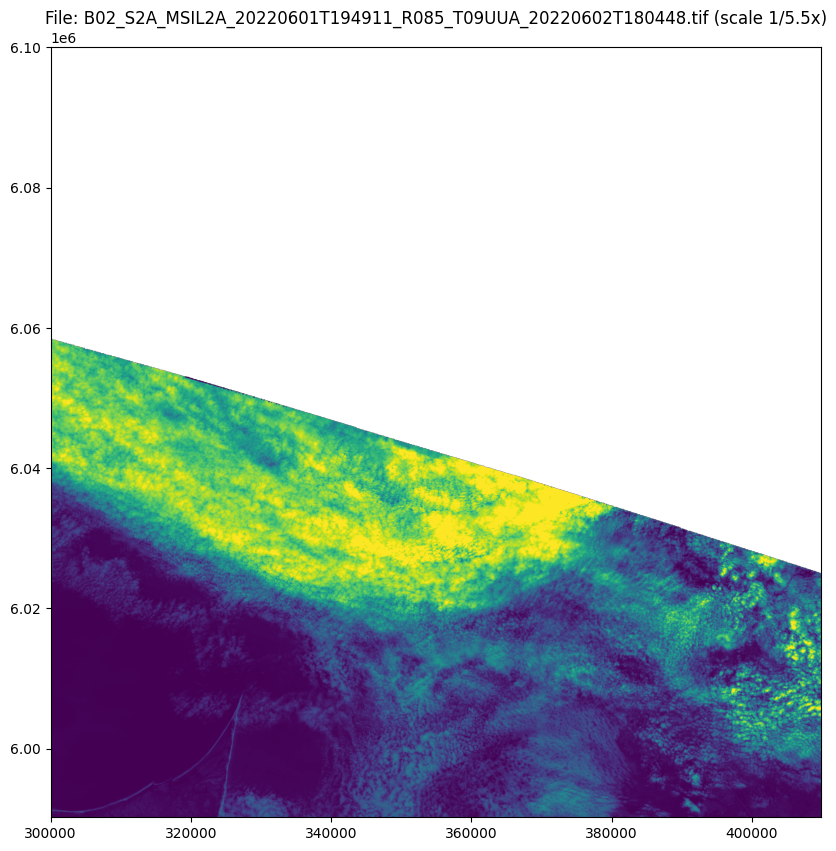

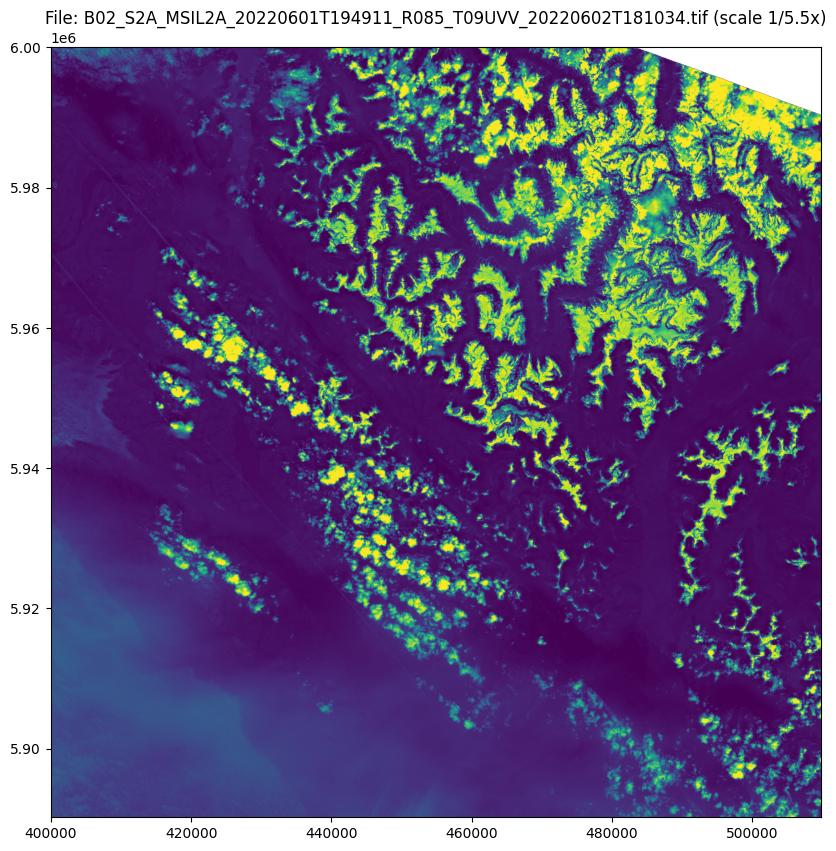

In [0]:
for b in ex_bands:
  if b is not None:
    plot_file(b)

In [0]:
print(f"""b02 total count? {sql("select format_number(count(1),0) from band_b02").first()[0]}""")
print(f"""b02 valid count? {sql("select format_number(count(1),0) from band_b02 where is_out_file_valid").first()[0]}""")
print(f"""b02 false count? {sql("select format_number(count(1),0) from band_b02 where is_out_file_valid = False").first()[0]}""")
print(f"""b02 null count?  {sql("select format_number(count(1),0) from band_b02 where is_out_file_valid is null").first()[0]}""")

b02 total count? 14
b02 valid count? 14
b02 false count? 0
b02 null count?  0


#### Optional: Repair Invalid Files

> Due to free-tier rate limits on [Planetary Computer](https://planetarycomputer.microsoft.com/docs/concepts/sas/), some download attempts may return an authentication-error XML payload rather than the actual GeoTIFF — for example:

```
<?xml version="1.0" encoding="utf-8"?><Error><Code>AuthenticationFailed</Code><Message>Server failed to authenticate the request. Make sure the value of Authorization header is formed correctly including the signature.
RequestId:bf21b919-d01e-002f-4e00-2ae765000000
Time:2023-12-08T18:04:30.9365583Z</Message><AuthenticationErrorDetail>Signature not valid in the specified time frame: Start [Thu, 07 Dec 2023 17:18:15 GMT] - Expiry [Fri, 08 Dec 2023 18:03:15 GMT] - Current [Fri, 08 Dec 2023 18:04:30 GMT]</AuthenticationErrorDetail></Error>
```

`stac_client.repair()` handles recovery: it reads the rows where `is_out_file_valid = false` from the named Delta table, re-downloads those assets (re-signing each href fresh per attempt), and MERGEs the updated rows back into the table. No manual tracking of which files failed is needed.

__Note:__ Delta MERGE [[1](https://docs.databricks.com/en/delta/merge.html#language-python)] is used under the hood so only the affected rows are updated.

__Repair any invalid files for B02__

> After downloading, check validity and repair any rows where `is_out_file_valid = false`. `stac_client.repair()` re-downloads the affected assets (re-signing each href per attempt) and merges the updated rows back into the Delta table. Since B02 is typically fully valid after the first run, the call is a no-op in the normal case.

In [0]:
# Check if any invalid files need repair after download
invalid_b02 = sql("SELECT count(1) FROM band_b02 WHERE is_out_file_valid = false").first()[0]
if invalid_b02 > 0:
    # stac_client.repair() expects asset_name column; band tables use band_name.
    # Use build_band_table with force_rebuild to re-download any invalid files.
    print(f"Re-downloading {invalid_b02:,} invalid B02 file(s) via build_band_table...")
    build_band_table("B02", eod_item_df, force_rebuild=True)
else:
    print("No invalid B02 files — repair not needed.")
print(f"invalid before repair: {invalid_b02:,}")

No invalid B02 files — repair not needed.
invalid before repair: 0


In [0]:
%sql SELECT * from band_b02 limit 3

item_id,band_name,date,out_file_path,out_file_sz,is_out_file_valid,last_update
S2A_MSIL2A_20220601T194911_R085_T09UUV_20220602T173354,B02,2022-06-01,/Volumes/geospatial_docs/eo_series/data/alaska/B02/B02_S2A_MSIL2A_20220601T194911_R085_T09UUV_20220602T173354.tif,184515222,true,2026-06-22T20:28:04.402Z
S2A_MSIL2A_20220601T194911_R085_T08UPG_20220602T195342,B02,2022-06-01,/Volumes/geospatial_docs/eo_series/data/alaska/B02/B02_S2A_MSIL2A_20220601T194911_R085_T08UPG_20220602T195342.tif,63273397,true,2026-06-22T20:28:04.402Z
S2A_MSIL2A_20220601T194911_R085_T08VPH_20220602T200243,B02,2022-06-01,/Volumes/geospatial_docs/eo_series/data/alaska/B02/B02_S2A_MSIL2A_20220601T194911_R085_T08VPH_20220602T200243.tif,21275175,true,2026-06-22T20:28:04.402Z


_Notice the new compact schema: `item_id`, `band_name`, `date`, `out_file_path`, `out_file_sz`, `is_out_file_valid`, `last_update` — exactly the columns notebooks 03 and 04 expect._

In [0]:
print(f"""b02 total count? {sql("select format_number(count(1),0) from band_b02").first()[0]}""")
print(f"""b02 valid count? {sql("select format_number(count(1),0) from band_b02 where is_out_file_valid").first()[0]}""")
print(f"""b02 false count? {sql("select format_number(count(1),0) from band_b02 where is_out_file_valid = False").first()[0]}""")
print(f"""b02 null count?  {sql("select format_number(count(1),0) from band_b02 where is_out_file_valid is null").first()[0]}""")

b02 total count? 14
b02 valid count? 14
b02 false count? 0
b02 null count?  0


_`stac_client.repair()` accepts either a table name (string) or a DataFrame. The `where` filter defaults to `"is_out_file_valid = false"` — pass a more specific predicate to scope the repair to a subset (e.g. a single `item_id`)._

### Download Any / All Other Bands

> This loop downloads all four bands used in the series (B02, B03, B04, B08). It can be rerun safely: `build_band_table` skips bands whose tables already exist when `FORCE_REBUILD=False`, and `stac_client.download()` skips files already present and valid on disk.

_This downloads GeoTIFFs per band per day for the target area. The operation can take some time depending on cluster size, whether starting fresh, and free-tier throttling from Planetary Computer. Because `stac_client.download()` validates each file on receipt and re-signs per attempt, interrupted runs can be safely resumed — already-valid files are skipped, and any invalid rows can be recovered with `stac_client.repair()`._

In [0]:
for band in ['B02', 'B03', 'B04', 'B08']:
    print(f"working on band '{band}'...")
    build_band_table(band, eod_item_df, FORCE_REBUILD)

display(dbutils.fs.ls(f"{EO_DIR}"))

working on band 'B02'...
working on band 'B03'...
working on band 'B04'...
working on band 'B08'...


path,name,size,modificationTime
dbfs:/Volumes/geospatial_docs/eo_series/data/alaska/B02/,B02/,0,1782241721867
dbfs:/Volumes/geospatial_docs/eo_series/data/alaska/B03/,B03/,0,1782241721867
dbfs:/Volumes/geospatial_docs/eo_series/data/alaska/B04/,B04/,0,1782241721867
dbfs:/Volumes/geospatial_docs/eo_series/data/alaska/B08/,B08/,0,1782241721867
dbfs:/Volumes/geospatial_docs/eo_series/data/alaska/_gbxrepair_B02/,_gbxrepair_B02/,0,1782241721867
dbfs:/Volumes/geospatial_docs/eo_series/data/alaska/_gbxverify_B02/,_gbxverify_B02/,0,1782241721867
dbfs:/Volumes/geospatial_docs/eo_series/data/alaska/cell_assets_20260620-164651.delta/,cell_assets_20260620-164651.delta/,0,1782241721867
dbfs:/Volumes/geospatial_docs/eo_series/data/alaska/out/,out/,0,1782241721867


_See all the tables generated._

In [0]:
for band in ['B02', 'B03', 'B04', 'B08']:
  print(f"::: '{band}' :::")
  df_band = spark.table(f"band_{band}")
  print(f"""\ttotal?            {df_band.count():,}""")
  print(f"""\tis valid?         {df_band.filter(F.expr("is_out_file_valid = True")).count():,}""")
  print(f"""\tnot valid?        {df_band.filter(F.expr("is_out_file_valid = False")).count():,}""")
  print(f"""\tunknown validity? {df_band.filter(F.expr("is_out_file_valid is null")).count():,}""")
  print("")

::: 'B02' :::
	total?            14
	is valid?         14
	not valid?        0
	unknown validity? 0

::: 'B03' :::
	total?            14
	is valid?         14
	not valid?        0
	unknown validity? 0

::: 'B04' :::
	total?            14
	is valid?         14
	not valid?        0
	unknown validity? 0

::: 'B08' :::
	total?            14
	is valid?         14
	not valid?        0
	unknown validity? 0



_Look at the directories where the bands were downloaded._

In [0]:
display(dbutils.fs.ls(EO_DIR))

path,name,size,modificationTime
dbfs:/Volumes/geospatial_docs/eo_series/data/alaska/B02/,B02/,0,1782241728324
dbfs:/Volumes/geospatial_docs/eo_series/data/alaska/B03/,B03/,0,1782241728324
dbfs:/Volumes/geospatial_docs/eo_series/data/alaska/B04/,B04/,0,1782241728324
dbfs:/Volumes/geospatial_docs/eo_series/data/alaska/B08/,B08/,0,1782241728325
dbfs:/Volumes/geospatial_docs/eo_series/data/alaska/_gbxrepair_B02/,_gbxrepair_B02/,0,1782241728325
dbfs:/Volumes/geospatial_docs/eo_series/data/alaska/_gbxverify_B02/,_gbxverify_B02/,0,1782241728325
dbfs:/Volumes/geospatial_docs/eo_series/data/alaska/cell_assets_20260620-164651.delta/,cell_assets_20260620-164651.delta/,0,1782241728325
dbfs:/Volumes/geospatial_docs/eo_series/data/alaska/out/,out/,0,1782241728325
